In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from fcmeans import FCM
from kneed import KneeLocator

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [2]:
# Selecting k number of clusters
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

# funtion to identify optimum k 
def OptimumK(scaled_vals, maxK):
    # by default test from 2 up to 30 centers
    # A list holds the SSE values for each k
    sse = []
    # A list holds the silhouette coefficients for each k
    silhouette_coefficients = []
    
    for k in range(2, maxK):
        kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
        kmeans.fit(scaled_vals)
        
        # elbow method
        sse.append(kmeans.inertia_)
        # silhouette    method
        score = silhouette_score(scaled_vals, kmeans.labels_)
        silhouette_coefficients.append(score)    

    # optimum elbow
    kl = KneeLocator( range(2, maxK), sse, curve="convex", direction="decreasing")
    
    return sse, silhouette_coefficients, kl.elbow

def OptimumK_short(scaled_vals, maxK):
    # by default test from 2 up to 30 centers
    # A list holds the SSE values for each k
    # return only elbow value
    sse = []
    # A list holds the silhouette coefficients for each k
    silhouette_coefficients = []
    
    for k in range(2, maxK):
        kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
        kmeans.fit(scaled_vals)
        # elbow method
        sse.append(kmeans.inertia_)
        # silhouette    method
        #score = silhouette_score(scaled_vals, kmeans.labels_)
        #silhouette_coefficients.append(score)    

    # optimum elbow
    kl = KneeLocator( range(2, maxK), sse, curve="convex", direction="decreasing")
    return kl.elbow
        


In [3]:
def PlotQC_kmeans(sse_vals, elbow, silhouette_vals, ktested):
    f, axes = plt.subplots(1, 2, figsize=(15,5))
    
    axes[0].plot(range(2, ktested), sse_vals, lw=2)
    axes[0].set_xticks(range(2, ktested, 2))
    axes[0].set(xlabel="Number of Clusters", ylabel="SSE")    
    axes[0].axvline(x=elbow, linestyle='--', lw=2)
    #
    axes[1].plot(range(2, ktested), silhouette_vals, lw=2)
    axes[1].set_xticks(range(2, ktested, 2))
    axes[1].set(xlabel="Number of Clusters", ylabel="Silhouette Coefficient")
    #plt.savefig('images/basic-clustering-output.jpg')
    plt.show()



In [35]:
## pecanpy results from weighted combined network
# uniqFullNets_weighted.txt
#alldf = pd.read_csv('Pecanpy_uniqFullNets_weighted.txt', sep=" ", skiprows=[0], header=None)
alldf = pd.read_csv('Pecanpy_uFNetsW.Dim128_WL80_nW10.txt', sep=" ", skiprows=[0], header=None)
alldf = alldf.set_index(0)



In [36]:
# df as numpy arrays
sf_all = alldf.to_numpy()


In [37]:
# First round testing
all_r1_opts = OptimumK(sf_all, 40)

In [38]:
print(all_r1_opts[2])


15


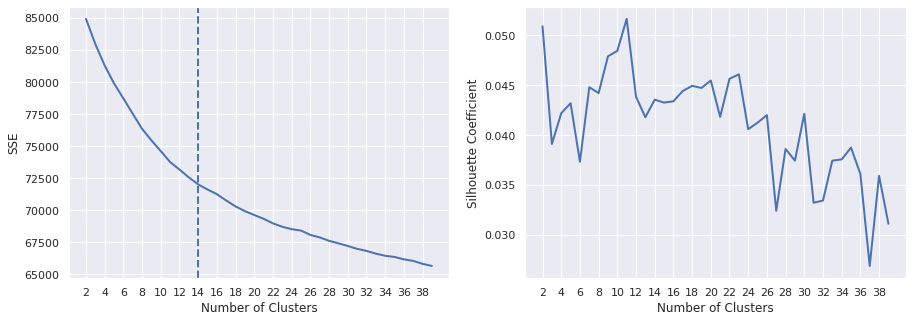

In [23]:
# Dim100_WL50_nW50
#PlotQC_kmeans(all_r1_opts[0], all_r1_opts[2], all_r1_opts[1], 40)

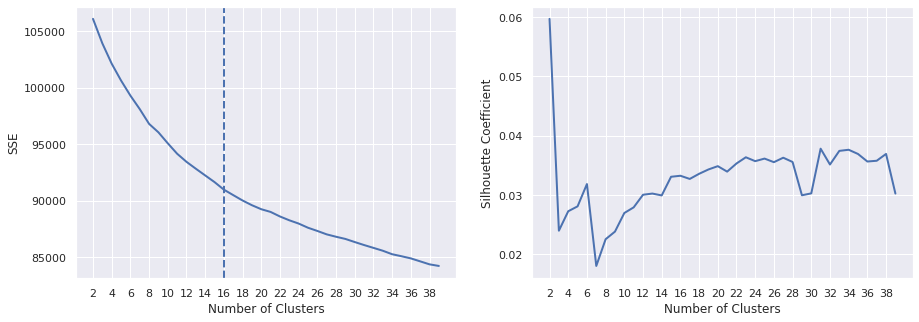

In [43]:
# Dim100_WL50_nW100
#PlotQC_kmeans(all_r1_opts[0], all_r1_opts[2], all_r1_opts[1], 40)

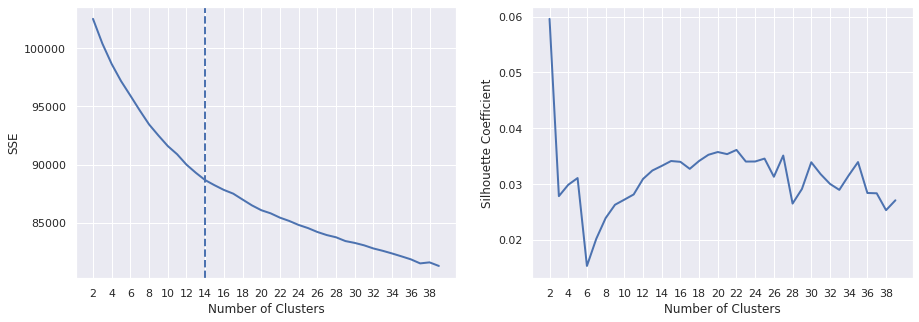

In [59]:
# Dim100_WL100_nW50
#PlotQC_kmeans(all_r1_opts[0], all_r1_opts[2], all_r1_opts[1], 40)

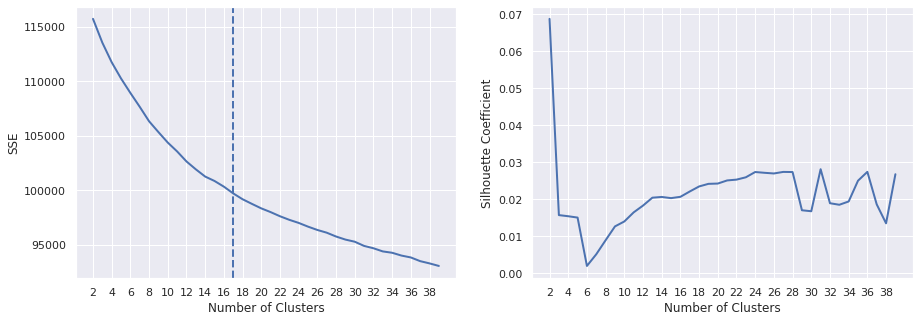

In [8]:
# Dim100_WL100_nW100
#PlotQC_kmeans(all_r1_opts[0], all_r1_opts[2], all_r1_opts[1], 40)

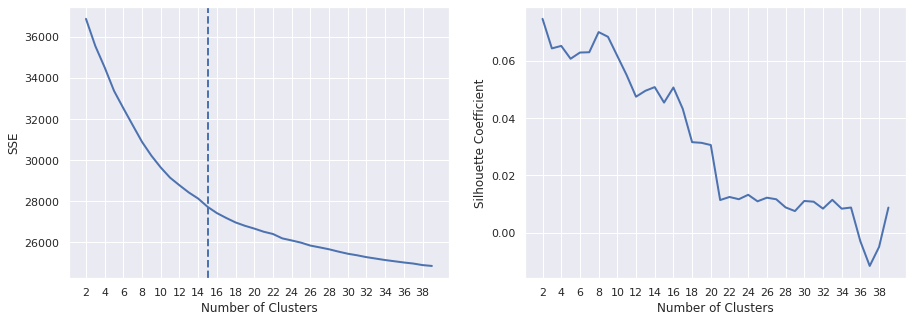

In [39]:
# Dim128_WL80_nW10
# PlotQC_kmeans(all_r1_opts[0], all_r1_opts[2], all_r1_opts[1], 40)

In [9]:
# after first round: 
## All layers     k=16
print(all_r1_opts[2])

17


In [40]:
# all layers
R1_all_kmeans = KMeans(n_clusters=35, **kmeans_kwargs)
R1_all_kmeans.fit(sf_all)

# make df with labes and gene ids
R1_Kmean  = pd.DataFrame({'GeneID':alldf.index, 'Module_K':R1_all_kmeans.labels_, 'Round':1}) 

# set GeneID as index
R1_Kmean = R1_Kmean.set_index('GeneID')
R1_Kmean["Module_K"] = pd.to_numeric(R1_Kmean["Module_K"])
R1_Kmean
print(all_r1_opts[2])

15


In [41]:
# Dim100_WL50_nW50: Genes by cluster: 35
R1_Kmean.groupby('Module_K').count()

,Round
Module_K,
0,1052
1,666
2,826
3,1163
4,128
5,1299
6,718
7,4047
8,74


In [42]:
# Dim100_WL50_nW50: Genes by cluster: 22
R1_Kmean.groupby('Module_K').count()

,Round
Module_K,
0,1052
1,666
2,826
3,1163
4,128
5,1299
6,718
7,4047
8,74


In [43]:
# define list of modules in round 1
K_Modules_1  = R1_Kmean.Module_K.unique()

In [44]:
# optimum numbed of clusters using all layers

K_elbows_R1 = []

for M in K_Modules_1:
        # Genes in module M
        
        # From original DF, extract only genes in cluster M
        tem = alldf.loc[R1_Kmean[R1_Kmean["Module_K"] == M].index]
        tem = tem.to_numpy()
        print(tem.shape)
        #
        sub_elbows = OptimumK_short(tem, 20)
        
        K_elbows_R1.append(sub_elbows)
        size = tem.shape
        print("Module {}: genes {} and Obt K: {}".format(M, size[0], sub_elbows))
        

# sse.append(kmeans.inertia_)
#
K_elbows_R1

(1599, 128)
Module 9: genes 1599 and Obt K: 7
(2272, 128)
Module 16: genes 2272 and Obt K: 9
(2031, 128)
Module 13: genes 2031 and Obt K: 7
(1472, 128)
Module 14: genes 1472 and Obt K: 7
(860, 128)
Module 22: genes 860 and Obt K: 7
(1052, 128)
Module 0: genes 1052 and Obt K: 7
(620, 128)
Module 33: genes 620 and Obt K: 9
(4047, 128)
Module 7: genes 4047 and Obt K: 8
(1096, 128)
Module 20: genes 1096 and Obt K: 7
(839, 128)
Module 15: genes 839 and Obt K: 8
(214, 128)
Module 29: genes 214 and Obt K: 9
(128, 128)
Module 4: genes 128 and Obt K: 10
(74, 128)
Module 8: genes 74 and Obt K: 9
(863, 128)
Module 11: genes 863 and Obt K: 7
(893, 128)
Module 23: genes 893 and Obt K: 8
(826, 128)
Module 2: genes 826 and Obt K: 7
(361, 128)
Module 31: genes 361 and Obt K: 8
(666, 128)
Module 1: genes 666 and Obt K: 8
(718, 128)
Module 6: genes 718 and Obt K: 8
(500, 128)
Module 12: genes 500 and Obt K: 6
(858, 128)
Module 30: genes 858 and Obt K: 10
(688, 128)
Module 34: genes 688 and Obt K: 8
(583

[7,
 9,
 7,
 7,
 7,
 7,
 9,
 8,
 7,
 8,
 9,
 10,
 9,
 7,
 8,
 7,
 8,
 8,
 8,
 6,
 10,
 8,
 9,
 6,
 6,
 7,
 10,
 8,
 7,
 9,
 7,
 9,
 8,
 7,
 7]

In [45]:
###############################################################
# Second round of kmeans using optimum elbows from Rounds 1
###############################################################

# for i in range(0, len(All_Modules_1)):

R2_all = pd.DataFrame([])


for i in range(0, len(K_Modules_1)):
    print([K_Modules_1[i], K_elbows_R1[i]])
    
    M = K_Modules_1[i]
    
    # Subset initial DF
    tem = alldf.loc[R1_Kmean[R1_Kmean["Module_K"] == M].index]
    # save genes ids
    # print(tem.shape)
    tem_genes = tem.index
    print('gene index len: {}'.format(len(tem_genes)))
    #
    tem = tem.to_numpy()
    # kmeans 
    R2_all_ks = KMeans(n_clusters=K_elbows_R1[i], **kmeans_kwargs)
    R2_all_ks.fit(tem)
    
    # make module index combining first and second round of clustering
    
    index_modules = [ (str(M)+'_') + str(i) for i in R2_all_ks.labels_]
    print('number of labels: {}'.format(len(index_modules)))    
    #print(index_modules)
    #
    R2_all_ks = pd.DataFrame({'GeneID':tem_genes, 'K1':M, 'k2':R2_all_ks.labels_, 'Module': index_modules}) 
    R2_all = R2_all.append(R2_all_ks)
    #
R2_all

[9, 7]
gene index len: 1599
number of labels: 1599
[16, 9]
gene index len: 2272
number of labels: 2272
[13, 7]
gene index len: 2031
number of labels: 2031
[14, 7]
gene index len: 1472
number of labels: 1472
[22, 7]
gene index len: 860
number of labels: 860
[0, 7]
gene index len: 1052
number of labels: 1052
[33, 9]
gene index len: 620
number of labels: 620
[7, 8]
gene index len: 4047
number of labels: 4047
[20, 7]
gene index len: 1096
number of labels: 1096
[15, 8]
gene index len: 839
number of labels: 839
[29, 9]
gene index len: 214
number of labels: 214
[4, 10]
gene index len: 128
number of labels: 128
[8, 9]
gene index len: 74
number of labels: 74
[11, 7]
gene index len: 863
number of labels: 863
[23, 8]
gene index len: 893
number of labels: 893
[2, 7]
gene index len: 826
number of labels: 826
[31, 8]
gene index len: 361
number of labels: 361
[1, 8]
gene index len: 666
number of labels: 666
[6, 8]
gene index len: 718
number of labels: 718
[12, 6]
gene index len: 500
number of labels:

,GeneID,K1,k2,Module
0,Zm00001d049364,9,4,9_4
1,Zm00001d024324,9,4,9_4
2,Zm00001d048623,9,4,9_4
3,Zm00001d002762,9,4,9_4
4,Zm00001d002364,9,4,9_4
...,...,...,...,...
1713,Zm00001d033856,24,6,24_6
1714,Zm00001d050536,24,5,24_5
1715,Zm00001d032445,24,5,24_5
1716,Zm00001d046635,24,2,24_2


In [46]:
# save results
R2_all.to_csv("Two_Kmean_to_Dim128_WL80_nW10.txt", sep='\t', index=False)

#



In [47]:
R2_all

,GeneID,K1,k2,Module
0,Zm00001d049364,9,4,9_4
1,Zm00001d024324,9,4,9_4
2,Zm00001d048623,9,4,9_4
3,Zm00001d002762,9,4,9_4
4,Zm00001d002364,9,4,9_4
...,...,...,...,...
1713,Zm00001d033856,24,6,24_6
1714,Zm00001d050536,24,5,24_5
1715,Zm00001d032445,24,5,24_5
1716,Zm00001d046635,24,2,24_2


In [48]:
R2_all.groupby('Module').count()

,GeneID,K1,k2
Module,,,
0_0,184,184,184
0_1,16,16,16
0_2,231,231,231
0_3,158,158,158
0_4,233,233,233
...,...,...,...
9_2,288,288,288
9_3,301,301,301
9_4,21,21,21
